In [ ]:
import pandas as pd

### Phân phối các biến số (Numerical Features Distribution)

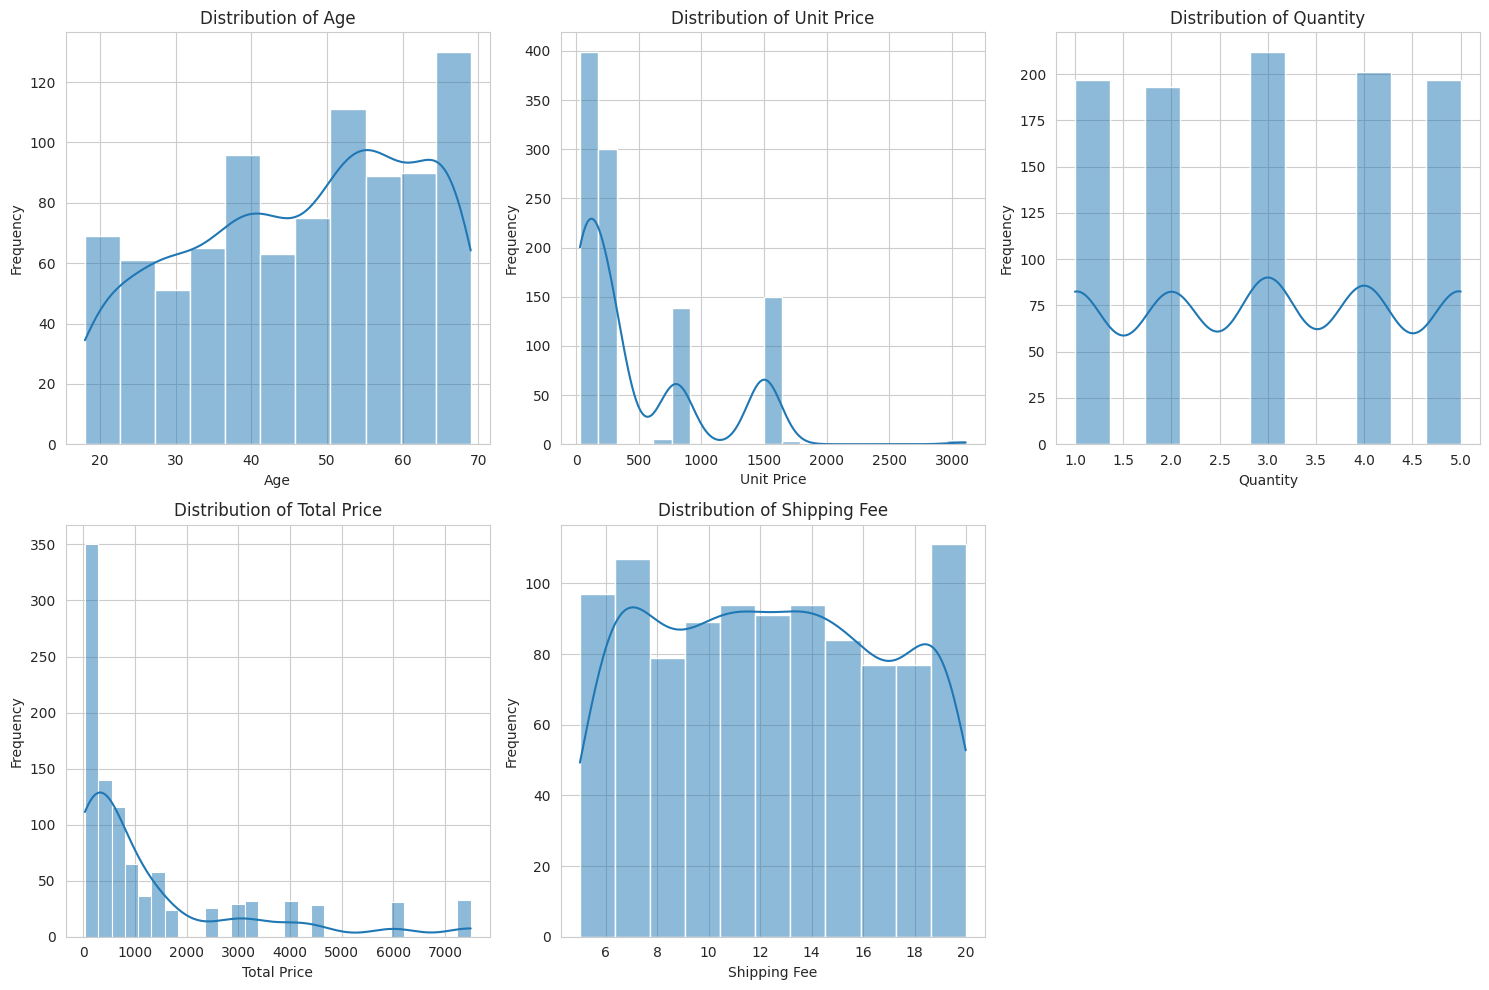

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for plots
sns.set_style('whitegrid')

# Columns to plot histograms for
numerical_cols = ['Age', 'Unit Price', 'Quantity', 'Total Price', 'Shipping Fee']

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i) # 2 rows, 3 columns
    sns.histplot(df[col].dropna(), kde=True) # dropna() to handle missing values
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

### Phân phối các biến phân loại (Categorical Features Distribution)

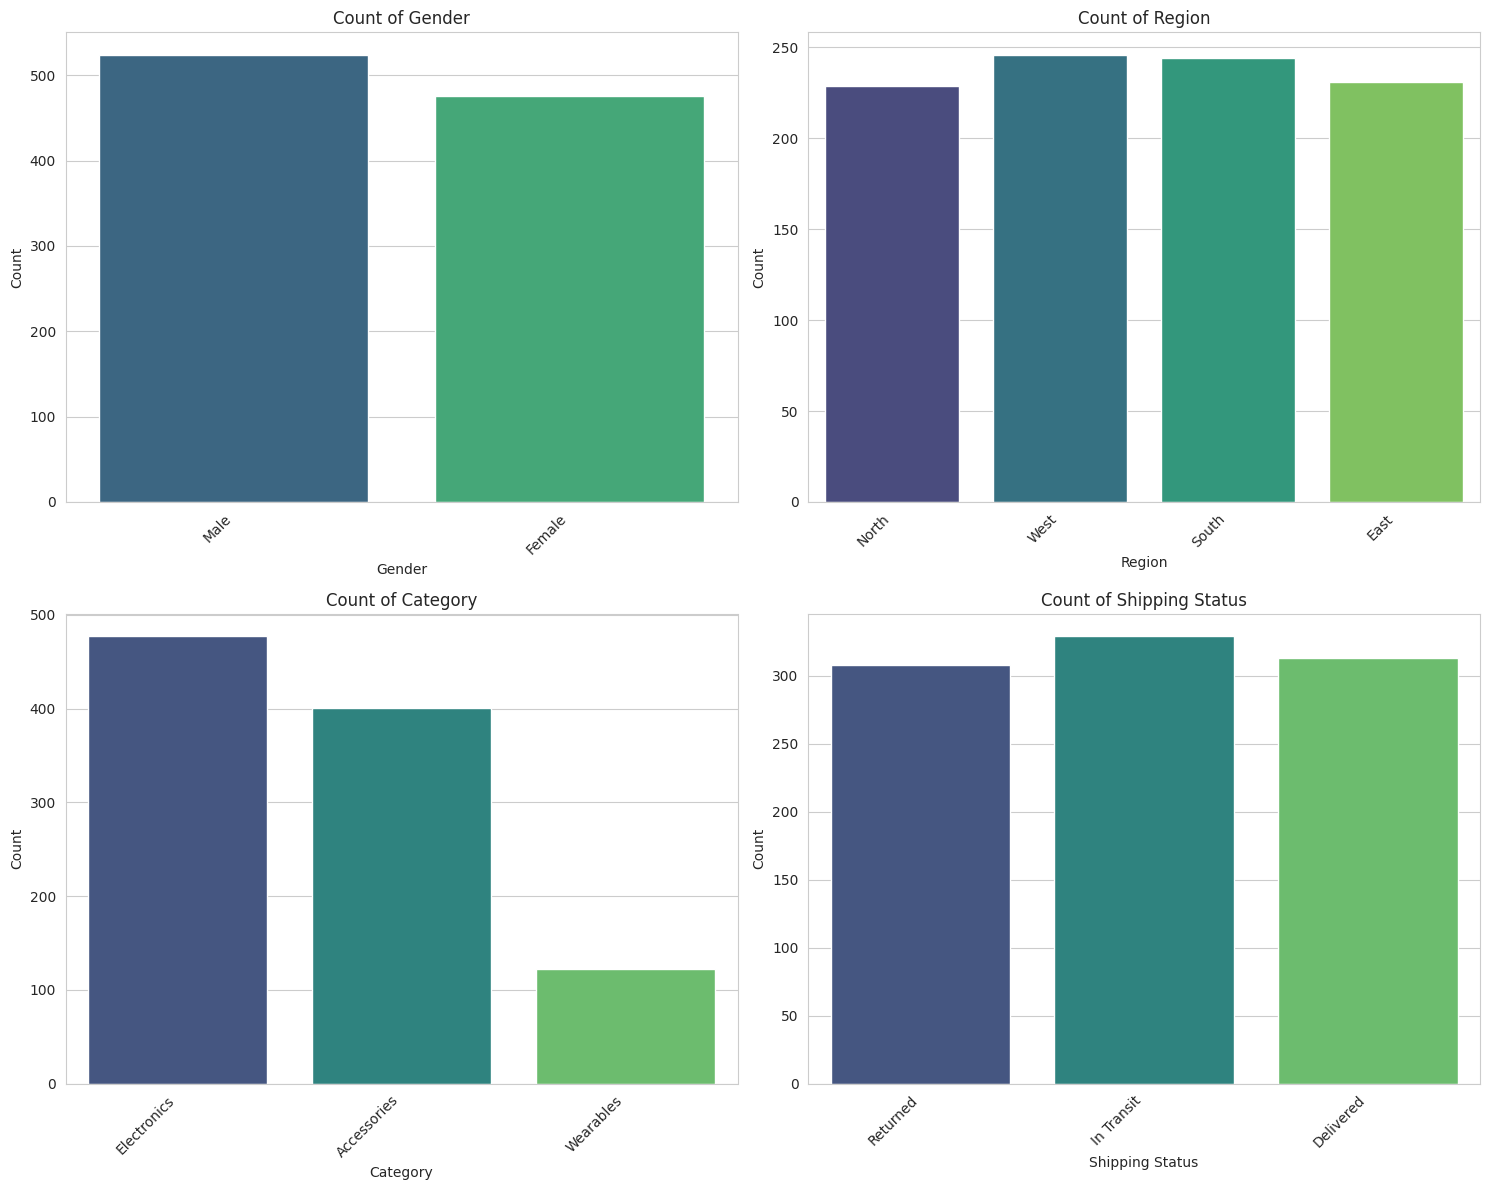

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Columns to plot bar charts for
categorical_cols = ['Gender', 'Region', 'Category', 'Shipping Status']

plt.figure(figsize=(15, 12))
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(2, 2, i) # 2 rows, 2 columns
    sns.countplot(data=df, x=col, palette='viridis', hue=col, legend=False) # Add hue=col and legend=False to address FutureWarning
    plt.title(f'Count of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

### Doanh số theo thời gian (Sales Over Time)

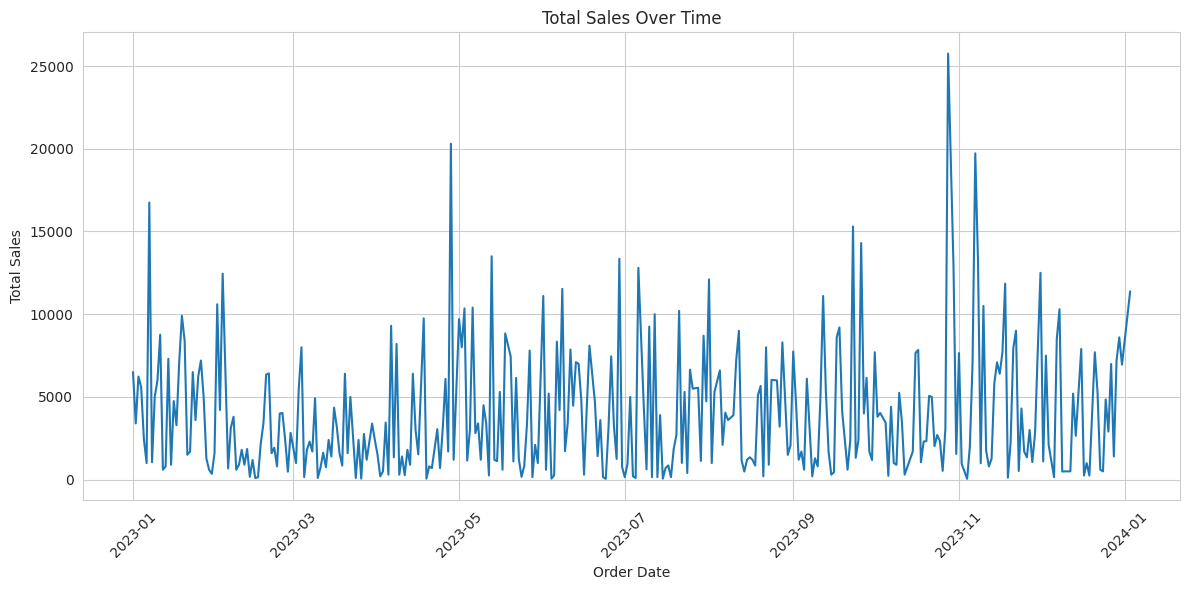

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Ensure 'Order Date' is a datetime object
df['Order Date'] = pd.to_datetime(df['Order Date'])

# Aggregate total sales by date
daily_sales = df.groupby('Order Date')['Total Price'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(data=daily_sales, x='Order Date', y='Total Price')
plt.title('Total Sales Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Thông tin tổng quan về Bộ dữ liệu (Dataset Overview)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      1000 non-null   object        
 1   Gender           1000 non-null   object        
 2   Region           950 non-null    object        
 3   Age              900 non-null    float64       
 4   Product Name     1000 non-null   object        
 5   Category         1000 non-null   object        
 6   Unit Price       1000 non-null   float64       
 7   Quantity         1000 non-null   int64         
 8   Total Price      1000 non-null   int64         
 9   Shipping Fee     1000 non-null   float64       
 10  Shipping Status  950 non-null    object        
 11  Order Date       1000 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 93.9+ KB


### Xử lý giá trị bị thiếu (Handling Missing Values)

In [ ]:
print(f"Shape of DataFrame before dropping nulls: {df.shape}")

df_cleaned = df.dropna()

print(f"Shape of DataFrame after dropping nulls: {df_cleaned.shape}")
print("Đã loại bỏ các hàng có giá trị bị thiếu. Bây giờ bạn có thể làm việc với `df_cleaned`.")

Shape of DataFrame before dropping nulls: (1000, 12)
Shape of DataFrame after dropping nulls: (810, 12)
Đã loại bỏ các hàng có giá trị bị thiếu. Bây giờ bạn có thể làm việc với `df_cleaned`.


### Thông tin tổng quan về Bộ dữ liệu sau khi làm sạch (Dataset Overview After Cleaning)

In [ ]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 810 entries, 1 to 998
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Customer ID      810 non-null    object        
 1   Gender           810 non-null    object        
 2   Region           810 non-null    object        
 3   Age              810 non-null    float64       
 4   Product Name     810 non-null    object        
 5   Category         810 non-null    object        
 6   Unit Price       810 non-null    float64       
 7   Quantity         810 non-null    int64         
 8   Total Price      810 non-null    int64         
 9   Shipping Fee     810 non-null    float64       
 10  Shipping Status  810 non-null    object        
 11  Order Date       810 non-null    datetime64[ns]
dtypes: datetime64[ns](1), float64(3), int64(2), object(6)
memory usage: 82.3+ KB


### Chia tách dữ liệu (Data Splitting)

In [ ]:
from sklearn.model_selection import train_test_split

# Xác định các đặc trưng (features) và biến mục tiêu (target)
# Trong ví dụ này, chúng ta sẽ xem 'Total Price' là biến mục tiêu
# và các cột còn lại (trừ Customer ID, Product Name, Order Date) là đặc trưng.
# Bạn có thể điều chỉnh các cột này tùy theo mục tiêu phân tích của mình.

X = df_cleaned.drop(columns=['Customer ID', 'Total Price', 'Product Name', 'Order Date'])
y = df_cleaned['Total Price']

# Chia tách dữ liệu thành tập huấn luyện (80%) và tập kiểm tra (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Kích thước của tập huấn luyện X_train: {X_train.shape}")
print(f"Kích thước của tập kiểm tra X_test: {X_test.shape}")
print(f"Kích thước của biến mục tiêu y_train: {y_train.shape}")
print(f"Kích thước của biến mục tiêu y_test: {y_test.shape}")

Kích thước của tập huấn luyện X_train: (648, 8)
Kích thước của tập kiểm tra X_test: (162, 8)
Kích thước của biến mục tiêu y_train: (648,)
Kích thước của biến mục tiêu y_test: (162,)


### Huấn luyện Mô hình Hồi quy Tuyến tính (Linear Regression Model Training)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import joblib
import os

# Xác định các đặc trưng số và đặc trưng phân loại
numerical_features = ['Age', 'Unit Price', 'Quantity', 'Shipping Fee']
categorical_features = ['Gender', 'Region', 'Category', 'Shipping Status']

# Tạo pipeline tiền xử lý cho các đặc trưng số
numerical_transformer = Pipeline(steps=[
    ('scaler', StandardScaler()) # Chuẩn hóa các đặc trưng số
])

# Tạo pipeline tiền xử lý cho các đặc trưng phân loại
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Mã hóa One-Hot các đặc trưng phân loại
])

# Kết hợp các bộ tiền xử lý bằng ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Tạo pipeline cuối cùng bao gồm tiền xử lý và mô hình hồi quy tuyến tính
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression()) # Sử dụng mô hình Hồi quy Tuyến tính
])

# Huấn luyện mô hình
model.fit(X_train, y_train)

print("Mô hình hồi quy tuyến tính đã được huấn luyện thành công!")

# --- Lưu mô hình ---
# Lấy đường dẫn thư mục của dataset đã tải
dataset_path = '/content/drive/MyDrive/Colab Notebooks/ PREDICTING PRODUCT SALES/realistic_e_commerce_sales_data.csv'
model_save_dir = os.path.dirname(dataset_path)

# Tạo tên file cho mô hình đã lưu
model_filename = os.path.join(model_save_dir, 'linear_regression_model.joblib')

# Lưu mô hình vào file
joblib.dump(model, model_filename)
print(f"Mô hình đã được lưu tại: {model_filename}")

Mô hình hồi quy tuyến tính đã được huấn luyện thành công!
Mô hình đã được lưu tại: /content/drive/MyDrive/Colab Notebooks/ PREDICTING PRODUCT SALES/linear_regression_model.joblib


### Hiển thị các Biểu đồ Đánh giá Mô hình

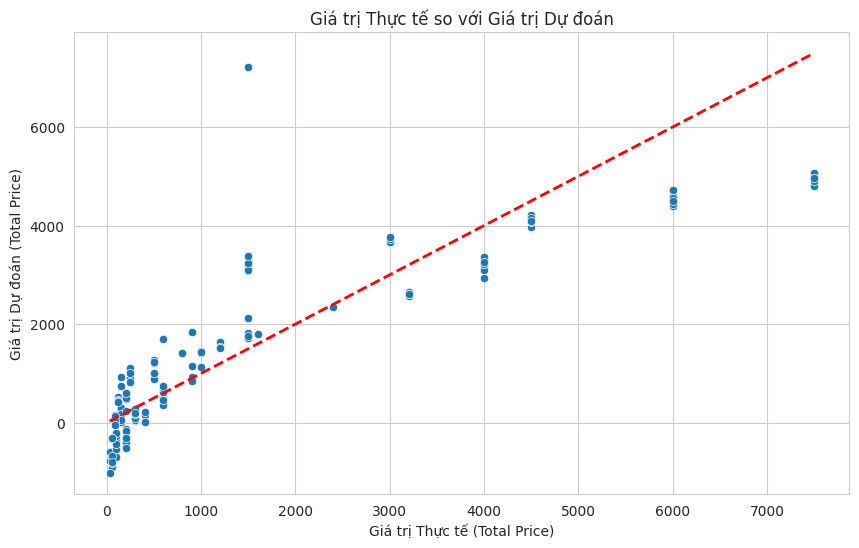

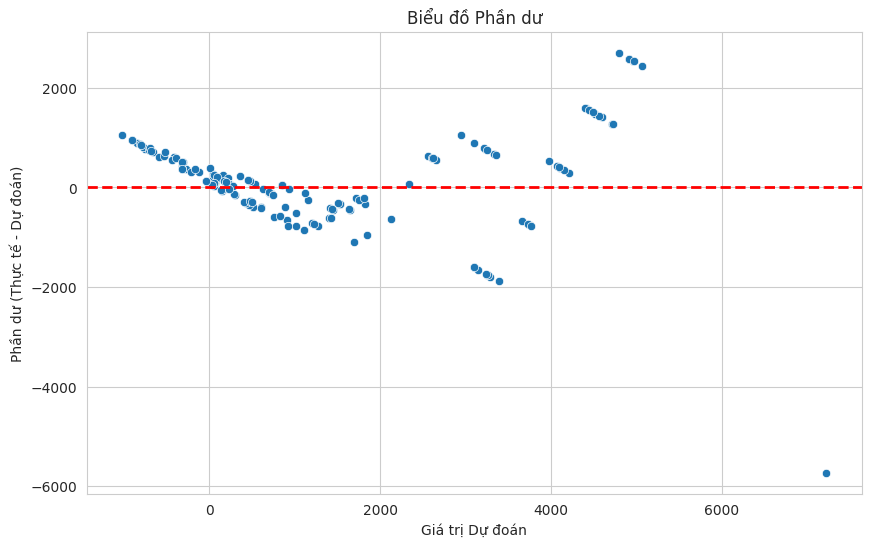

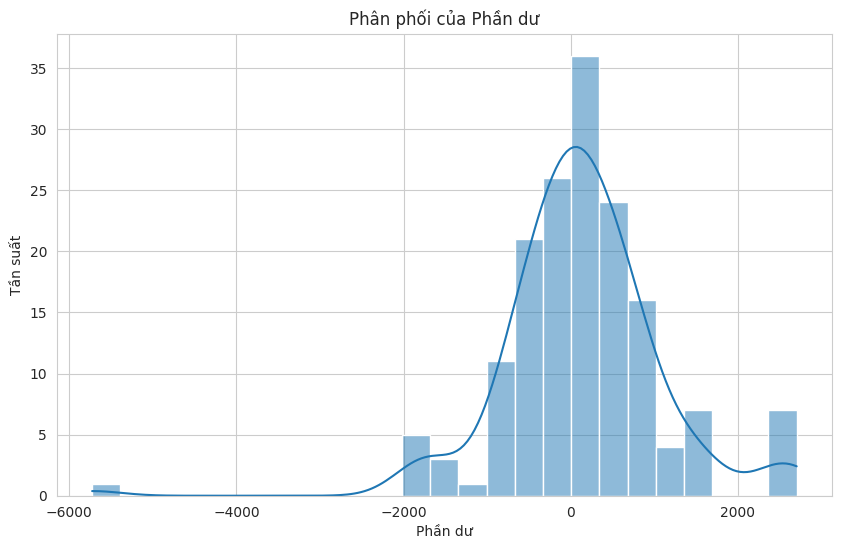

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Biểu đồ Giá trị Dự đoán so với Giá trị Thực tế ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Đường 45 độ
plt.title('Giá trị Thực tế so với Giá trị Dự đoán')
plt.xlabel('Giá trị Thực tế (Total Price)')
plt.ylabel('Giá trị Dự đoán (Total Price)')
plt.grid(True)
plt.show()

# --- 2. Biểu đồ Phần dư (Residual Plot) ---
residuals = y_test - y_pred
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Đường tham chiếu tại 0
plt.title('Biểu đồ Phần dư')
plt.xlabel('Giá trị Dự đoán')
plt.ylabel('Phần dư (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()

# --- 3. Biểu đồ Phân phối Phần dư ---
plt.figure(figsize=(10, 6))
sns.histplot(residuals, kde=True)
plt.title('Phân phối của Phần dư')
plt.xlabel('Phần dư')
plt.ylabel('Tần suất')
plt.grid(True)
plt.show()

### Huấn luyện Mô hình Hồi quy Đa thức (Polynomial Regression Model Training)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
import joblib
import os

# Xác định các đặc trưng số và đặc trưng phân loại
numerical_features_poly = ['Age', 'Unit Price', 'Quantity', 'Shipping Fee']
categorical_features_poly = ['Gender', 'Region', 'Category', 'Shipping Status']

# Tạo pipeline tiền xử lý cho các đặc trưng số, bao gồm PolynomialFeatures
numerical_transformer_poly = Pipeline(steps=[
    ('scaler', StandardScaler()), # Chuẩn hóa các đặc trưng số
    ('poly', PolynomialFeatures(degree=2, include_bias=False)) # Thêm đặc trưng đa thức
])

# Tạo pipeline tiền xử lý cho các đặc trưng phân loại
categorical_transformer_poly = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore')) # Mã hóa One-Hot các đặc trưng phân loại
])

# Kết hợp các bộ tiền xử lý bằng ColumnTransformer
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer_poly, numerical_features_poly),
        ('cat', categorical_transformer_poly, categorical_features_poly)
    ])

# Tạo pipeline cuối cùng bao gồm tiền xử lý và mô hình hồi quy tuyến tính
model_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('regressor', LinearRegression()) # Sử dụng mô hình Hồi quy Tuyến tính
])

# Huấn luyện mô hình
model_poly.fit(X_train, y_train)

print("Mô hình hồi quy đa thức đã được huấn luyện thành công!")

# --- Đánh giá mô hình ---
# Dự đoán trên tập kiểm tra
y_pred_poly = model_poly.predict(X_test)

# Tính toán và in ra độ chính xác (R-squared) của mô hình
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Độ chính xác (R-squared) của mô hình hồi quy đa thức trên tập kiểm tra: {r2_poly:.4f}")

# --- Lưu mô hình ---
# Lấy đường dẫn thư mục của dataset đã tải
dataset_path = '/content/drive/MyDrive/Colab Notebooks/ PREDICTING PRODUCT SALES/realistic_e_commerce_sales_data.csv'
model_save_dir = os.path.dirname(dataset_path)

# Tạo tên file cho mô hình đã lưu
model_filename_poly = os.path.join(model_save_dir, 'polynomial_regression_model.joblib')

# Lưu mô hình vào file
joblib.dump(model_poly, model_filename_poly)
print(f"Mô hình đã được lưu tại: {model_filename_poly}")

Mô hình hồi quy đa thức đã được huấn luyện thành công!
Độ chính xác (R-squared) của mô hình hồi quy đa thức trên tập kiểm tra: 0.9737
Mô hình đã được lưu tại: /content/drive/MyDrive/Colab Notebooks/ PREDICTING PRODUCT SALES/polynomial_regression_model.joblib


### Hiển thị các Biểu đồ Đánh giá Mô hình Hồi quy Đa thức

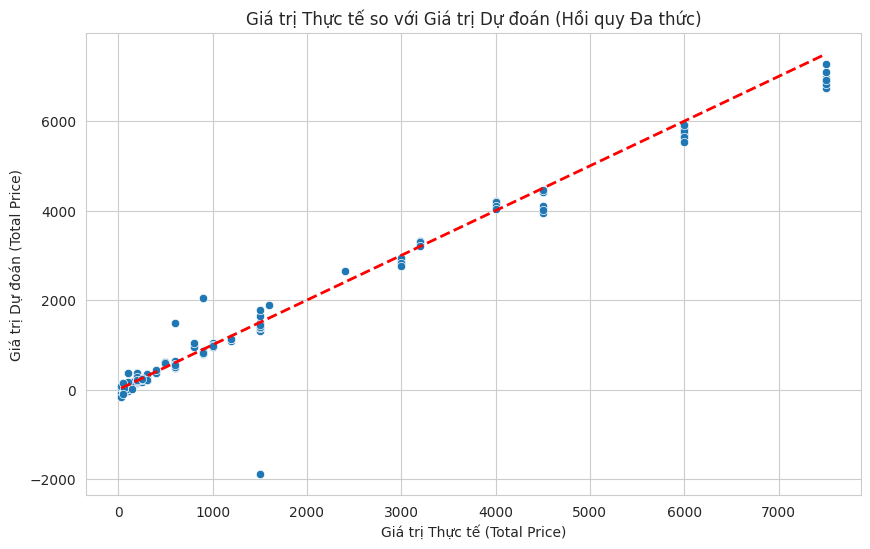

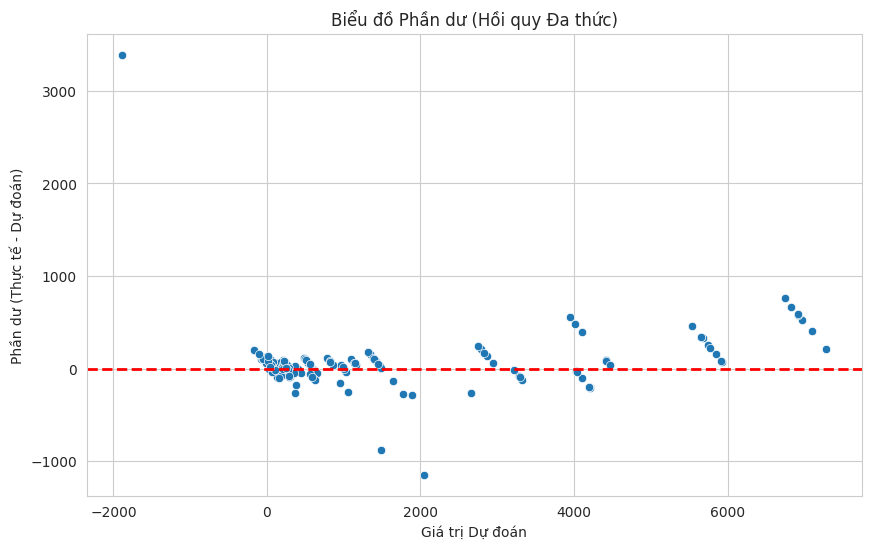

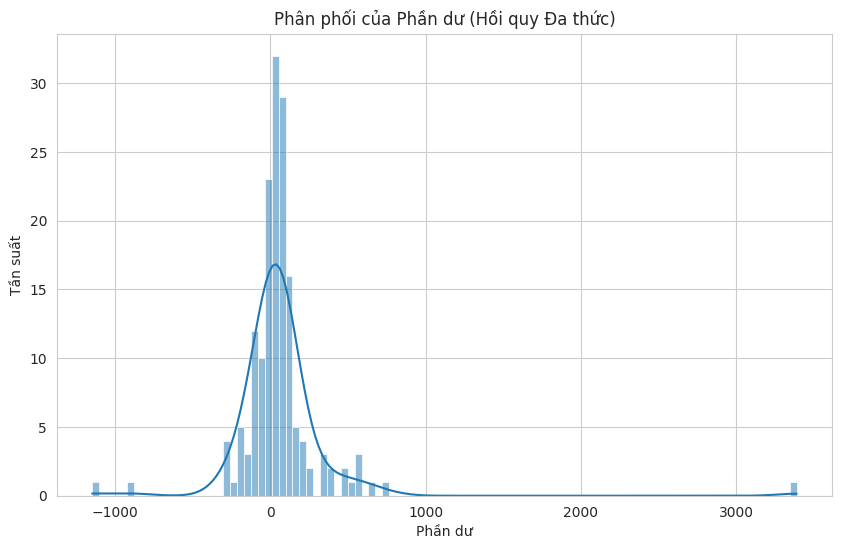

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- 1. Biểu đồ Giá trị Dự đoán so với Giá trị Thực tế (Hồi quy Đa thức) ---
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred_poly)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], '--r', linewidth=2) # Đường 45 độ
plt.title('Giá trị Thực tế so với Giá trị Dự đoán (Hồi quy Đa thức)')
plt.xlabel('Giá trị Thực tế (Total Price)')
plt.ylabel('Giá trị Dự đoán (Total Price)')
plt.grid(True)
plt.show()

# --- 2. Biểu đồ Phần dư (Residual Plot - Hồi quy Đa thức) ---
residuals_poly = y_test - y_pred_poly
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_pred_poly, y=residuals_poly)
plt.axhline(y=0, color='r', linestyle='--', linewidth=2) # Đường tham chiếu tại 0
plt.title('Biểu đồ Phần dư (Hồi quy Đa thức)')
plt.xlabel('Giá trị Dự đoán')
plt.ylabel('Phần dư (Thực tế - Dự đoán)')
plt.grid(True)
plt.show()

# --- 3. Biểu đồ Phân phối Phần dư (Hồi quy Đa thức) ---
plt.figure(figsize=(10, 6))
sns.histplot(residuals_poly, kde=True)
plt.title('Phân phối của Phần dư (Hồi quy Đa thức)')
plt.xlabel('Phần dư')
plt.ylabel('Tần suất')
plt.grid(True)
plt.show()